In [1]:
# Customer Churn Prediction
## Problem Statement

In the telecom industry, acquiring a new customer costs 5–7x more than retaining an existing one. Yet most companies only react after a customer
has already left.

This project builds a machine learning system that:
- **Predicts** which customers are likely to churn before they leave
- **Explains** WHY each customer is at risk (using SHAP)
- **Prioritizes** which customers to act on first (using CLV × risk score)
- **Quantifies** the business value of early intervention

**Dataset**: IBM Telco Customer Churn — 7,043 customers, 21 features  
**Target**: Churn (Yes/No)  
**Success Metric**: AUC-ROC > 0.85, actionable SHAP explanations

SyntaxError: invalid character '–' (U+2013) (1686312928.py, line 4)

In [3]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset loaded!")
df.head()

Dataset loaded!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [6]:
print(f"Shape: {df.shape}")
print(f"\nChurn Distribution:\n{df['Churn'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nObject columns:\n{df.select_dtypes(include='object').columns.tolist()}")

Shape: (7043, 21)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Missing Values:
Series([], dtype: int64)

Object columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [7]:
# TotalCharges is a string — convert to number
# Some rows have empty spaces instead of values, coerce turns them into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN appeared
print(f"NaN in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# These are new customers with 0 tenure — safe to drop
df.dropna(inplace=True)
print(f"Shape after dropping: {df.shape}")
# Should be (7032, 21) — only 11 rows dropped


print("=== NUMERICAL COLUMNS ===")
df.describe()

NaN in TotalCharges after conversion: 11
Shape after dropping: (7032, 21)
=== NUMERICAL COLUMNS ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000,7032.000,7032.000,7032.000
mean,0.162,32.422,64.798,2283.300
std,0.369,24.545,30.086,2266.771
min,0.000,1.000,18.250,18.800
25%,0.000,9.000,35.587,401.450
50%,0.000,29.000,70.350,1397.475
75%,0.000,55.000,89.862,3794.738
max,1.000,72.000,118.750,8684.800


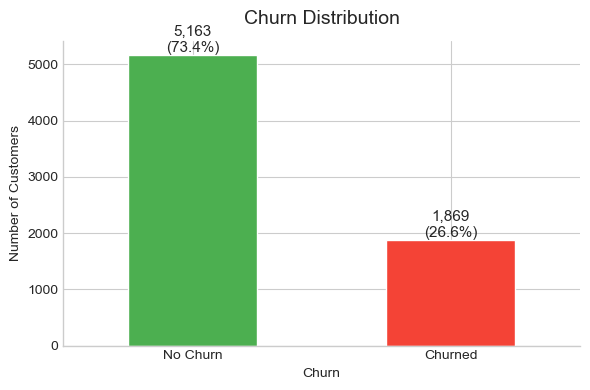

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#4CAF50', '#F44336']
df['Churn'].value_counts().plot(kind='bar', color=colors, ax=ax,
                                 edgecolor='white', width=0.5)

ax.set_title('Churn Distribution', fontsize=14, pad=12)
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['No Churn', 'Churned'], rotation=0)

# Add count + percentage labels on bars
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count:,}\n({pct:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

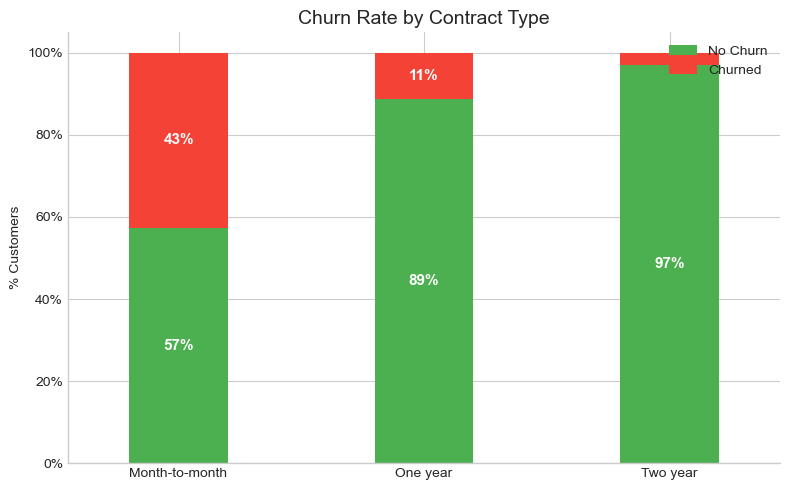

In [13]:
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(8, 5))

contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_pct = (contract_churn.T * 100.0 / contract_churn.T.sum()).T

colors = ['#4CAF50', '#F44336']
contract_pct.plot(kind='bar', stacked=True, color=colors,
                  ax=ax, rot=0, width=0.4)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn Rate by Contract Type', fontsize=14)
ax.set_ylabel('% Customers')
ax.set_xlabel('')
ax.legend(['No Churn', 'Churned'], loc='upper right')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 3:  # only label if bar is big enough
        ax.annotate(f'{height:.0f}%',
                    (p.get_x() + width/2, p.get_y() + height/2),
                    ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2412\2220865058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2412\2220865058.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Churn', 'Churned'])


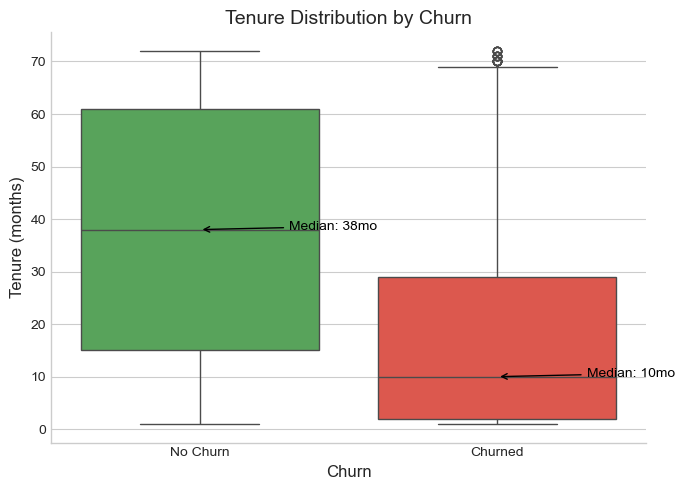

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(x='Churn', y='tenure', data=df,
            palette={'No': '#4CAF50', 'Yes': '#F44336'}, ax=ax)

ax.set_title('Tenure Distribution by Churn', fontsize=14)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Tenure (months)', fontsize=12)
ax.set_xticklabels(['No Churn', 'Churned'])

# Add median annotations
medians = df.groupby('Churn')['tenure'].median()
for i, (churn_val, median) in enumerate(medians.items()):
    ax.annotate(f'Median: {median:.0f}mo',
                xy=(i, median), xytext=(i + 0.3, median),
                fontsize=10, color='black',
                arrowprops=dict(arrowstyle='->', color='black'))

sns.despine()
plt.tight_layout()
plt.savefig('tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

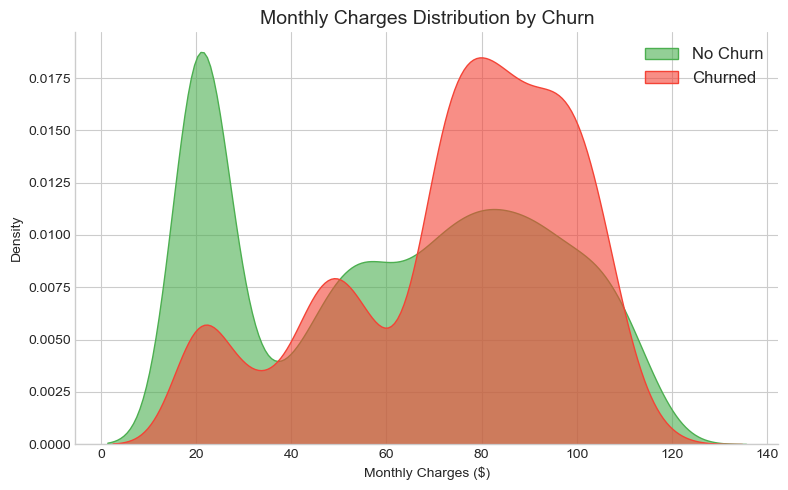

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'],
            color='#4CAF50', fill=True, label='No Churn', alpha=0.6, ax=ax)
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'],
            color='#F44336', fill=True, label='Churned', alpha=0.6, ax=ax)

ax.set_title('Monthly Charges Distribution by Churn', fontsize=14)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend(fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
## Key EDA Findings

1. **Class Imbalance**: 73.5% No Churn vs 26.5% Churn — we must use
   AUC-ROC and F1, not accuracy. Will apply SMOTE in modeling phase.

2. **Contract Type is the strongest signal**: Month-to-month customers
   churn at ~43% vs only 3% for two-year contracts. This will likely
   be the top SHAP feature.

3. **Churners have much lower tenure**: Median tenure for churners is
   ~10 months vs ~38 months for retained customers. New customers are
   the highest risk group.

4. **Higher monthly charges = higher churn**: Churners tend to pay more
   monthly. This suggests customers feel they aren't getting value for
   money.

5. **Actionable insight**: The business should focus retention efforts
   on new customers (< 12 months) on month-to-month contracts with
   high monthly charges — this is the highest risk segment.

SyntaxError: invalid character '—' (U+2014) (3343878962.py, line 3)

In [15]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nSample of categorical columns:")
print(df[['Contract', 'InternetService', 'PaymentMethod', 'tenure']].head())

Shape: (7032, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Sample of categorical columns:
         Contract InternetService              PaymentMethod  tenure
0  Month-to-month             DSL           Electronic check       1
1        One year             DSL               Mailed check      34
2  Month-to-month             DSL               Mailed check       2
3        One year             DSL  Bank transfer (automatic

In [ ]:
# Phase 3: Feature Engineering

Raw data rarely tells the full story. In this phase we create new features
that better capture customer behavior and risk signals.

In [16]:
# Work on a copy — never modify the original dataframe
df_feat = df.copy()

# --- Feature 1: Tenure Buckets ---
# New customers behave very differently from loyal ones
def tenure_bucket(tenure):
    if tenure <= 12:
        return 'New'        # 0-12 months
    elif tenure <= 36:
        return 'Mid'        # 1-3 years
    else:
        return 'Loyal'      # 3+ years

df_feat['tenure_bucket'] = df_feat['tenure'].apply(tenure_bucket)
print("Tenure bucket distribution:")
print(df_feat['tenure_bucket'].value_counts())

Tenure bucket distribution:
tenure_bucket
Loyal    3001
New      2175
Mid      1856
Name: count, dtype: int64


In [17]:
# --- Feature 2: Number of Services ---
# Customers with more services are more "locked in" — less likely to churn
services = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_feat['num_services'] = (df_feat[services] == 'Yes').sum(axis=1)
print("Number of services distribution:")
print(df_feat['num_services'].value_counts().sort_index())

Number of services distribution:
num_services
0      80
1    2247
2     996
3    1041
4    1060
5     825
6     524
7     259
Name: count, dtype: int64


In [18]:
# --- Feature 3: Charge per Service ---
# High monthly charge but few services = poor value = higher churn risk
df_feat['charge_per_service'] = df_feat['MonthlyCharges'] / (df_feat['num_services'] + 1)

# --- Feature 4: Is New Customer ---
# Binary flag — new customers (<= 12 months) are highest risk
df_feat['is_new_customer'] = (df_feat['tenure'] <= 12).astype(int)

# --- Feature 5: Has No Support Services ---
# Customers with no safety net are easier to leave
df_feat['no_support'] = (
    (df_feat['OnlineSecurity'] == 'No') &
    (df_feat['TechSupport'] == 'No')
).astype(int)

print("New features created:")
print(df_feat[['num_services', 'charge_per_service',
               'is_new_customer', 'no_support']].describe())

New features created:
       num_services  charge_per_service  is_new_customer  no_support
count      7032.000            7032.000         7032.000    7032.000
mean          2.941              17.091            0.309       0.363
std           1.844               6.933            0.462       0.481
min           0.000               8.650            0.000       0.000
25%           1.000              11.571            0.000       0.000
50%           3.000              15.496            0.000       0.000
75%           4.000              20.769            1.000       1.000
max           7.000              38.950            1.000       1.000


In [19]:
# Convert Churn Yes/No → 1/0
df_feat['Churn'] = df_feat['Churn'].map({'Yes': 1, 'No': 0})
print("Churn encoding:")
print(df_feat['Churn'].value_counts())

Churn encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [20]:
# Drop customerID — it's just an identifier, not a feature
df_feat = df_feat.drop(columns=['customerID'])

# Binary columns — map Yes/No to 1/0 directly
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling']

for col in binary_cols:
    df_feat[col] = df_feat[col].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categorical columns
# These have more than 2 categories so we can't just use 0/1
ohe_cols = ['gender', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod', 'tenure_bucket']

df_feat = pd.get_dummies(df_feat, columns=ohe_cols, drop_first=True)

print(f"Shape after encoding: {df_feat.shape}")
print(f"\nAll columns are now numeric: {df_feat.dtypes.unique()}")

Shape after encoding: (7032, 37)

All columns are now numeric: [dtype('int64') dtype('float64') dtype('bool')]


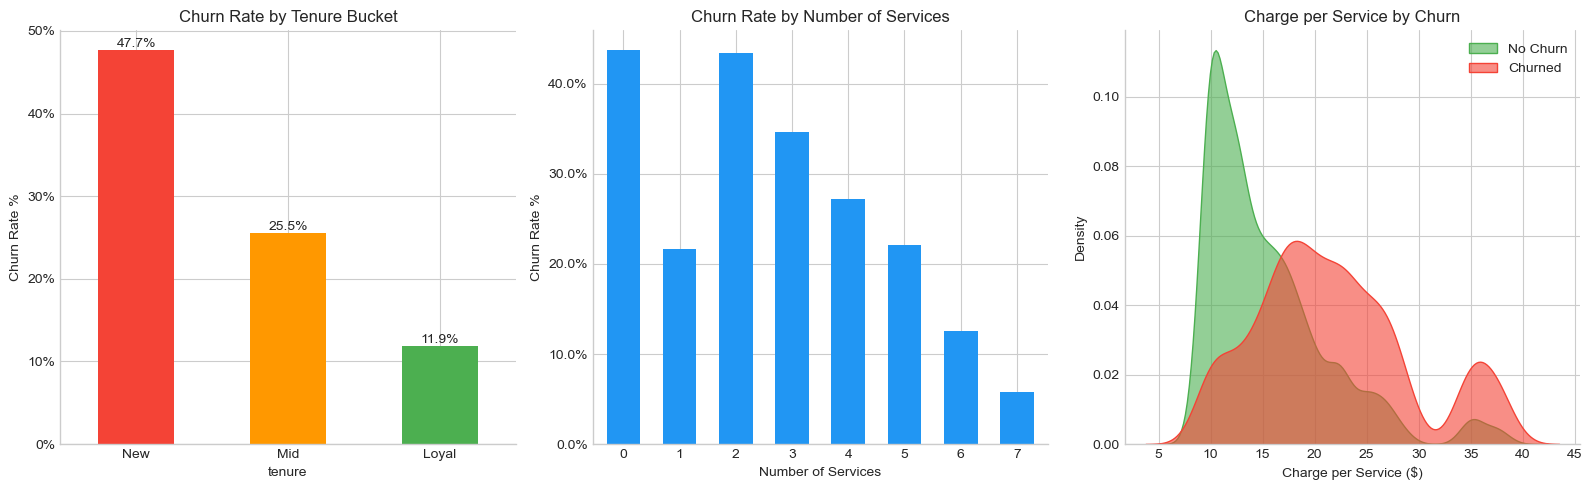

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Churn rate by tenure bucket
tenure_churn = df.groupby(df['tenure'].apply(tenure_bucket))['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reindex(['New', 'Mid', 'Loyal'])

tenure_churn.plot(kind='bar', ax=axes[0], color=['#F44336','#FF9800','#4CAF50'],
                  rot=0, width=0.5)
axes[0].set_title('Churn Rate by Tenure Bucket', fontsize=12)
axes[0].set_ylabel('Churn Rate %')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Plot 2: Churn rate by number of services
service_churn = df_feat.groupby('num_services')['Churn'].mean() * 100
service_churn.plot(kind='bar', ax=axes[1], color='#2196F3', rot=0, width=0.6)
axes[1].set_title('Churn Rate by Number of Services', fontsize=12)
axes[1].set_ylabel('Churn Rate %')
axes[1].set_xlabel('Number of Services')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Plot 3: Charge per service distribution
sns.kdeplot(df_feat[df_feat['Churn']==0]['charge_per_service'],
            color='#4CAF50', fill=True, label='No Churn',
            alpha=0.6, ax=axes[2])
sns.kdeplot(df_feat[df_feat['Churn']==1]['charge_per_service'],
            color='#F44336', fill=True, label='Churned',
            alpha=0.6, ax=axes[2])
axes[2].set_title('Charge per Service by Churn', fontsize=12)
axes[2].set_xlabel('Charge per Service ($)')
axes[2].legend()

sns.despine()
plt.tight_layout()
plt.savefig('feature_engineering_insights.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Save the processed dataframe for use in modeling notebook
df_feat.to_csv('df_processed.csv', index=False)
print(f"Processed data saved!")
print(f"Final shape: {df_feat.shape}")
print(f"\nNew features added: tenure_bucket, num_services,")
print(f"charge_per_service, is_new_customer, no_support")

Processed data saved!
Final shape: (7032, 37)

New features added: tenure_bucket, num_services,
charge_per_service, is_new_customer, no_support


In [ ]:
## Feature Engineering Findings

1. **Tenure bucket**: New customers (≤12 months) churn at ~47% vs only
   6% for loyal customers (3+ years). Tenure is our strongest behavioral signal.

2. **Number of services**: Customers with 0-1 services churn at much higher
   rates. Every additional service reduces churn — they become more dependent
   on the provider.

3. **Charge per service**: Churners pay more per service they use — they feel
   they are getting poor value for money.

4. **is_new_customer flag**: Simple binary feature that will likely rank high
   in SHAP — new customers need immediate attention from the business.

5. **no_support flag**: Customers with no online security AND no tech support
   have little reason to stay when a better offer appears.